# VAC Forming — Scrap Root-Cause Analysis & Recommendations  (FINAL)
**Inputs:** `data/VF_export.csv`, `data/VF_Scrap_export.csv` (Mar 11 – May 6, 2026)
**Companion:** `EDA.ipynb` (data audit), `FINDINGS.md` (methodology + open questions)

This notebook does the **diagnosis & recommendation** work. We do not claim what caused the data to look the way it does — we only describe what the parameters say about each defect and translate that into operating-window guidance.

### Method in one sentence
> For each `(tool, defect)` pair we compare *that defect's* parameter distributions against *good parts on the same tool*, drop recipe-fixed parameters, and combine effect size + significance + multivariate importance into a ranked list of corrective actions.


## 1. Setup

In [1]:
import os, warnings, json
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, brier_score_loss
plt.rcParams.update({'figure.figsize':(14,5),'font.size':11,'axes.titlesize':13})
sns.set_style('whitegrid')
pd.set_option('display.width', 240); pd.set_option('display.max_columns', 80)

## 2. Load & clean
Reuse the parsing from EDA, then **apply the cleaning decisions** the EDA established:
- Drop constants (`Pick Material Pos`, `TTF Circuit 2 Temp`).
- Treat `Machine Cycle Time = 9999` as missing (sentinel marker → `mct_capped` flag).
- Encode bimodal `Pos Vinyl *` as `_active` + value.
- Engineer warm-up (`is_warmup`, first 20 parts of day) and `prev_mct_capped` flags.


In [2]:
p_raw = pd.read_csv('../data/VF_export_new.csv').drop(columns=lambda c: c.startswith('Unnamed'), errors='ignore')
s_raw = pd.read_csv('../data/VF_Scrap_export.csv').drop(columns=lambda c: c.startswith('Unnamed'), errors='ignore')
p_raw['BuiltTime'] = pd.to_datetime(p_raw['BuiltTime'])
s_raw['ScrapTime'] = pd.to_datetime(s_raw['ScrapTime'])

def parse_kv(s):
    out = {}
    if pd.isna(s): return out
    for it in str(s).split(','):
        if ':' in it:
            k, v = it.rsplit(':', 1)
            try: out[k.strip()] = float(v.strip())
            except: pass
    return out

ds1 = p_raw['DS1'].apply(parse_kv).apply(pd.Series)
ds2 = p_raw['DS2'].apply(parse_kv).apply(pd.Series)
ds3 = p_raw['DS3'].apply(parse_kv).apply(pd.Series)
df = pd.concat([p_raw[['ID','PartDesc','BuiltTime']], ds1, ds2, ds3], axis=1)
df = df.merge(s_raw[['ID','Desc','ScrapTime']].rename(columns={'Desc':'defect','ScrapTime':'scrap_time'}),
              on='ID', how='left')
df['is_scrap'] = df['defect'].notna()

# --- Cleaning decisions (from EDA) ---
CONSTANTS = ['Pick Material Pos', 'TTF Circuit 2 Temp']
df = df.drop(columns=[c for c in CONSTANTS if c in df.columns])

df = df.sort_values('BuiltTime').reset_index(drop=True)
df['date'] = df['BuiltTime'].dt.date
df['hour'] = df['BuiltTime'].dt.hour
df['dow']  = df['BuiltTime'].dt.dayofweek
df['mct_capped'] = df['Machine Cycle Time'] == 9999
df.loc[df['mct_capped'], 'Machine Cycle Time'] = np.nan

POSV = ['Pos Vinyl N Length','Pos Vinyl N Width','Pos Vinyl S Length','Pos Vinyl S Width']
for c in POSV: df[f'{c}_active'] = (df[c] > 0).astype(int)

df['seq_in_day'] = df.groupby(['date','Tool Number']).cumcount()
df['is_warmup']  = (df['seq_in_day'] < 20).astype(int)
df['prev_mct_capped'] = (df.groupby('Tool Number')['mct_capped'].shift(1)
                          .fillna(False).astype(int))

df['color'] = df['PartDesc'].str.extract(r'\b(BLACK|BEIGE|WHITE)\b').fillna('OTHER')
df['family'] = df['PartDesc'].str.replace(r'\s+(BLACK|BEIGE|WHITE)$', '', regex=True)

PROCESS_DEFECTS = ['Wrinkle','Dent','Bumps / lumps','Burnt Carpet / Vynil',
                   'Low Glue/Read Thru/Impression','Out of dimension','Bad edge wrap',
                   'Glue bleed thru','Delamination']
df['scope'] = np.where(df['defect'].isna(),'Good',
              np.where(df['defect'].isin(PROCESS_DEFECTS),'Process','Non-Process'))
print(f'Rows: {len(df):,}   scrap: {df["is_scrap"].sum()} ({df["is_scrap"].mean()*100:.2f}%)')
print(f'Defect-scope:\n{df["scope"].value_counts().to_string()}')

Rows: 8,230   scrap: 386 (4.69%)
Defect-scope:
scope
Good           7844
Process         348
Non-Process      38


## 3. Tool-level and defect-tool exclusivity

The dataset is already tool-segmented in practice — different tools make different parts and produce different defects. Recommendations must therefore be `(tool, defect)`-specific.

Defect × Tool counts:
Tool Number                     1.0   2.0   8.0
defect                                         
Bad edge wrap                    20    12     0
Broken / Fracture                 2     1     1
Bumps / lumps                     0    17    35
Burnt Carpet / Vynil             10    26     7
Delamination                      0     0     1
Dent                             19    28    15
Fabric Flaw                       0     4     6
Fabric Torn                       0     6     1
Glue bleed thru                   1     0     0
Hole                              1    13     3
Low Glue/Read Thru/Impression     0    40     1
Out of dimension                 18     2     3
Wrinkle                          92     1     0
NaN                            2077  4258  1509

Per-tool scrap rate (Wilson 95% CI):
             parts  scrap  rate_pct  ci_low  ci_high
Tool Number                                         
1.0           2240    163      7.28    6.27     8.43
2.0          

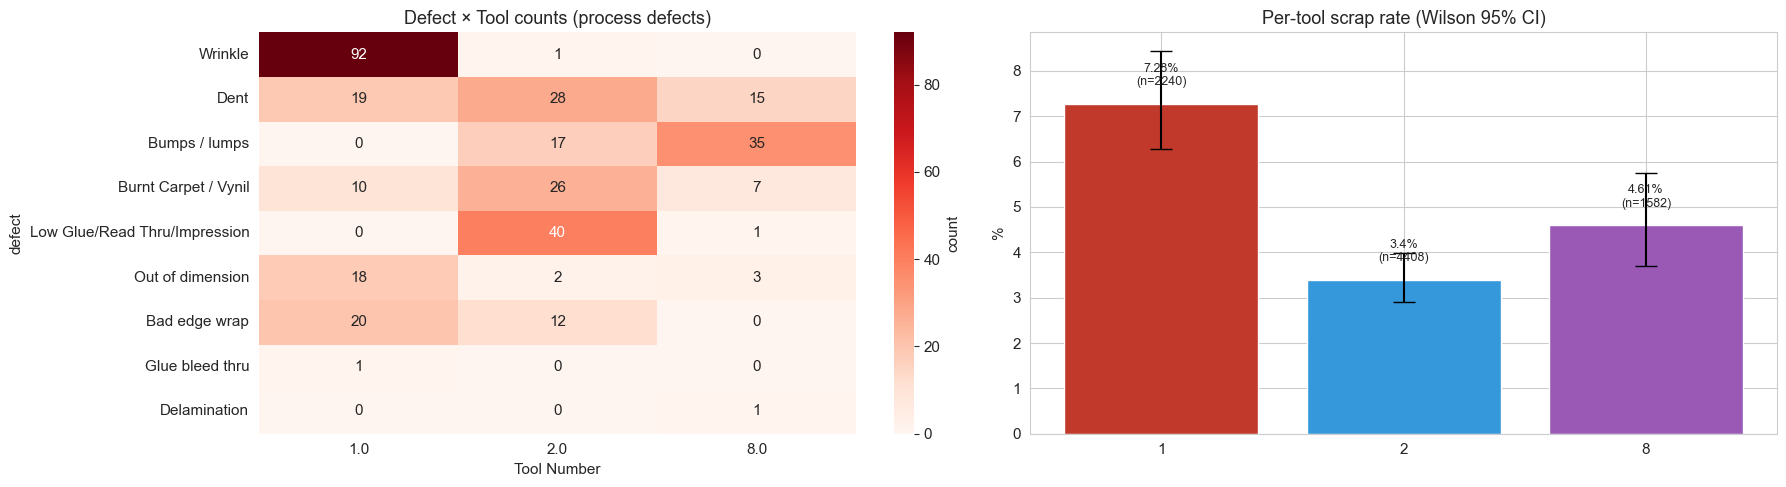

In [3]:
# Tool x defect crosstab + heatmap
ct = pd.crosstab(df['defect'], df['Tool Number'], dropna=False)
print('Defect × Tool counts:'); print(ct.to_string())

# Tool scrap rates with Wilson CI
def wilson(p,n,z=1.96):
    if n==0: return (np.nan,np.nan)
    den=1+z*z/n; cen=(p+z*z/(2*n))/den
    half=z*np.sqrt((p*(1-p)+z*z/(4*n))/n)/den
    return cen-half, cen+half

tool_summary = df.groupby('Tool Number').agg(parts=('ID','count'), scrap=('is_scrap','sum'))
tool_summary['rate_pct'] = (tool_summary['scrap']/tool_summary['parts']*100).round(2)
tool_summary[['ci_low','ci_high']] = [(round(lo*100,2), round(hi*100,2))
    for lo, hi in (wilson(r.scrap/r.parts, r.parts) for r in tool_summary.itertuples())]
print('\nPer-tool scrap rate (Wilson 95% CI):')
print(tool_summary.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18,5))
# Defect × Tool heatmap
sns.heatmap(ct.loc[PROCESS_DEFECTS] if all(d in ct.index for d in PROCESS_DEFECTS) else ct,
            annot=True, fmt='d', cmap='Reds', ax=axes[0], cbar_kws={'label':'count'})
axes[0].set_title('Defect × Tool counts (process defects)')

# Tool rates with CIs
errs_lo = (tool_summary['rate_pct'] - tool_summary['ci_low']).values
errs_hi = (tool_summary['ci_high'] - tool_summary['rate_pct']).values
xs = tool_summary.index.astype(int).astype(str)
axes[1].bar(xs, tool_summary['rate_pct'], yerr=[errs_lo, errs_hi], capsize=8,
            color=['#c0392b','#3498db','#9b59b6'])
for x, r in zip(xs, tool_summary.itertuples()):
    axes[1].text(x, r.rate_pct+0.4, f'{r.rate_pct}%\n(n={r.parts})', ha='center', fontsize=9)
axes[1].set_title('Per-tool scrap rate (Wilson 95% CI)'); axes[1].set_ylabel('%')
plt.tight_layout(); plt.show()

## 4. Within-tool variance audit

Parameters with very low within-tool CV are **recipe-fixed** — they cannot causally explain run-to-run scrap because they don't change. We keep only `CV > 0.01` and drop the rest from each tool's analysis.

In [4]:
PARAM_COLS = [c for c in df.columns if c not in
              ('ID','PartDesc','BuiltTime','date','hour','dow','color','family','defect',
               'scrap_time','is_scrap','scope','seq_in_day','is_warmup','mct_capped',
               'prev_mct_capped','Tool Number') and not c.endswith('_active')]

within_cv = (df.groupby('Tool Number')[PARAM_COLS]
               .agg(lambda x: x.std()/abs(x.mean()) if abs(x.mean())>1e-9 else 0))
print('CV summary (count of parameters in each band per tool):')
for t in within_cv.index:
    s = within_cv.loc[t]
    print(f'  Tool {int(t)}: drift>0.05: {(s>0.05).sum()}  marginal 0.01-0.05: {((s>0.01)&(s<=0.05)).sum()}  '
          f'recipe-fixed <0.01: {(s<=0.01).sum()}')

ACTIVE_PARAMS = {int(t): [p for p in PARAM_COLS if within_cv.loc[t, p] > 0.01]
                 for t in within_cv.index}
for t, ps in ACTIVE_PARAMS.items():
    print(f'\nTool {t} active params ({len(ps)}):')
    print('  ', ', '.join(ps))

CV summary (count of parameters in each band per tool):
  Tool 1: drift>0.05: 21  marginal 0.01-0.05: 2  recipe-fixed <0.01: 14
  Tool 2: drift>0.05: 17  marginal 0.01-0.05: 5  recipe-fixed <0.01: 15
  Tool 8: drift>0.05: 19  marginal 0.01-0.05: 1  recipe-fixed <0.01: 17

Tool 1 active params (23):
   Temp. THT at Trigger, Temp. BHT at Trigger, heating time (tens of seconds), Vacuum Time Tool Cavity A, Vacuum Time Tool Cavity B, BT Circuit 1 Temp, BT Circuit 2 Temp, Graining Vacuum TTF Cavity 1, Machine Cycle Time, Capacity THT, Capacity BHT, Time Feed to Vacuum 1, Pyro Clean, Pos Vinyl N Length, Pos Vinyl N Width, Pos Vinyl S Length, Pos Vinyl S Width, Roller Gap LH, Roller Gap RH, Temp Z1, Temp Z2, Temp Z3, Temp Z4

Tool 2 active params (22):
   Temp. THT at Trigger, Temp. BHT at Trigger, heating time (tens of seconds), Vacuum Time Tool Cavity A, Vacuum Time Tool Cavity B, BT Circuit 1 Temp, BT Circuit 2 Temp, TTF Circuit 1 Temp, Machine Cycle Time, Capacity THT, Capacity BHT, Time F

## 5. Diagnostic primitives — Welch t-test, Cliff's δ, RF importance

In [5]:
def cliffs_delta(bad, good):
    n1, n2 = len(bad), len(good)
    if not n1 or not n2: return np.nan
    u, _ = stats.mannwhitneyu(bad, good, alternative='two-sided')
    return (2*u)/(n1*n2) - 1

def deviation_table(defect, tool, params, df_):
    sub = df_[df_['Tool Number']==tool]
    g = sub[sub['scope']=='Good']
    b = sub[sub['defect']==defect]
    rows = []
    for p in params:
        gv = g[p].dropna().values; bv = b[p].dropna().values
        if len(gv) < 20 or len(bv) < 3 or np.std(gv) == 0: continue
        try:
            t, pv = stats.ttest_ind(gv, bv, equal_var=False)
        except Exception: continue
        rows.append({
            'param': p, 'n_bad': len(bv),
            'good_p5':  round(np.percentile(gv, 5), 2),
            'good_p50': round(np.percentile(gv, 50), 2),
            'good_p95': round(np.percentile(gv, 95), 2),
            'bad_p50':  round(np.percentile(bv, 50), 2),
            'pct_diff': round((bv.mean()-gv.mean())/gv.mean()*100, 2) if gv.mean() else np.nan,
            'cliffs':   round(cliffs_delta(bv, gv), 3),
            'welch_p':  pv,
        })
    out = pd.DataFrame(rows)
    if out.empty: return out
    out['abs_cliffs'] = out['cliffs'].abs()
    return out.sort_values('abs_cliffs', ascending=False)

def rf_importance_for(defect, tool, params, df_):
    sub = df_[df_['Tool Number']==tool]
    b = sub[sub['defect']==defect]; g = sub[sub['scope']=='Good']
    if len(b) < 15: return pd.Series(dtype=float)
    bal = pd.concat([b.assign(y=1),
                     g.sample(min(len(g), 3*len(b)), random_state=0).assign(y=0)])
    X = bal[params].fillna(bal[params].median()); y = bal['y'].values
    clf = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=5,
                                 class_weight='balanced', random_state=0, n_jobs=-1).fit(X, y)
    return pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Primitives defined.')

Primitives defined.


## 6. Per-(tool, defect) deep-dive

For each cell with ≥ 15 scrap cases we print: top deviations by absolute effect size, with directionality, statistical significance and per-tool good operating range.

In [6]:
SEVERITY = lambda d: 'CRITICAL' if abs(d) > 0.474 else ('STRONG' if abs(d) > 0.33 else 'MODERATE')

def deep_dive(defect):
    print('='*100); print(f' DEFECT: {defect}'); print('='*100)
    for tool in sorted(df['Tool Number'].dropna().unique()):
        n_bad = ((df['Tool Number']==tool) & (df['defect']==defect)).sum()
        if n_bad < 5: continue
        tab = deviation_table(defect, tool, ACTIVE_PARAMS[int(tool)], df)
        if tab.empty: continue
        sig = tab[(tab['welch_p'] < 0.05) & (tab['abs_cliffs'] > 0.2)].head(6)
        if sig.empty:
            print(f'\n Tool {int(tool)} | n_bad={n_bad} — no actionable signal at p<.05, |δ|>.2')
            continue
        print(f'\n Tool {int(tool)} | n_bad={n_bad}')
        for _, r in sig.iterrows():
            arrow = '↑' if r['cliffs']>0 else '↓'
            sev = SEVERITY(r['cliffs'])
            print(f'   {arrow} [{sev:<8}] {r["param"]:<35} good~{r["good_p50"]:<8} scrap~{r["bad_p50"]:<8} '
                  f'(Δ {r["pct_diff"]:+.1f}%)  δ={r["cliffs"]:+.2f}  p={r["welch_p"]:.1e}')

for d in ['Wrinkle','Dent','Bumps / lumps','Burnt Carpet / Vynil',
          'Low Glue/Read Thru/Impression','Out of dimension','Bad edge wrap']:
    deep_dive(d)

 DEFECT: Wrinkle

 Tool 1 | n_bad=92
   ↑ [STRONG  ] Pos Vinyl S Width                   good~249.0    scrap~253.0    (Δ +29.2%)  δ=+0.36  p=4.9e-39
   ↑ [MODERATE] Pos Vinyl N Length                  good~21.0     scrap~28.0     (Δ +61.1%)  δ=+0.29  p=3.7e-06
   ↓ [MODERATE] Roller Gap RH                       good~1.0      scrap~1.0      (Δ -30.3%)  δ=-0.27  p=2.4e-12
   ↓ [MODERATE] Roller Gap LH                       good~10.0     scrap~10.0     (Δ -3.7%)  δ=-0.26  p=1.4e-06
   ↓ [MODERATE] Vacuum Time Tool Cavity B           good~83.0     scrap~76.0     (Δ -7.2%)  δ=-0.23  p=1.8e-03
   ↓ [MODERATE] Vacuum Time Tool Cavity A           good~84.0     scrap~76.0     (Δ -4.1%)  δ=-0.20  p=5.7e-03
 DEFECT: Dent

 Tool 1 | n_bad=19
   ↑ [STRONG  ] Graining Vacuum TTF Cavity 1        good~1.0      scrap~2.0      (Δ +31.8%)  δ=+0.43  p=2.9e-04
   ↑ [STRONG  ] Pos Vinyl N Width                   good~23.0     scrap~28.0     (Δ +64.1%)  δ=+0.38  p=2.2e-04
   ↑ [MODERATE] Pyro Clean          

### 6.1 Visual confirmation — Wrinkle on Tool 1 (largest single defect)

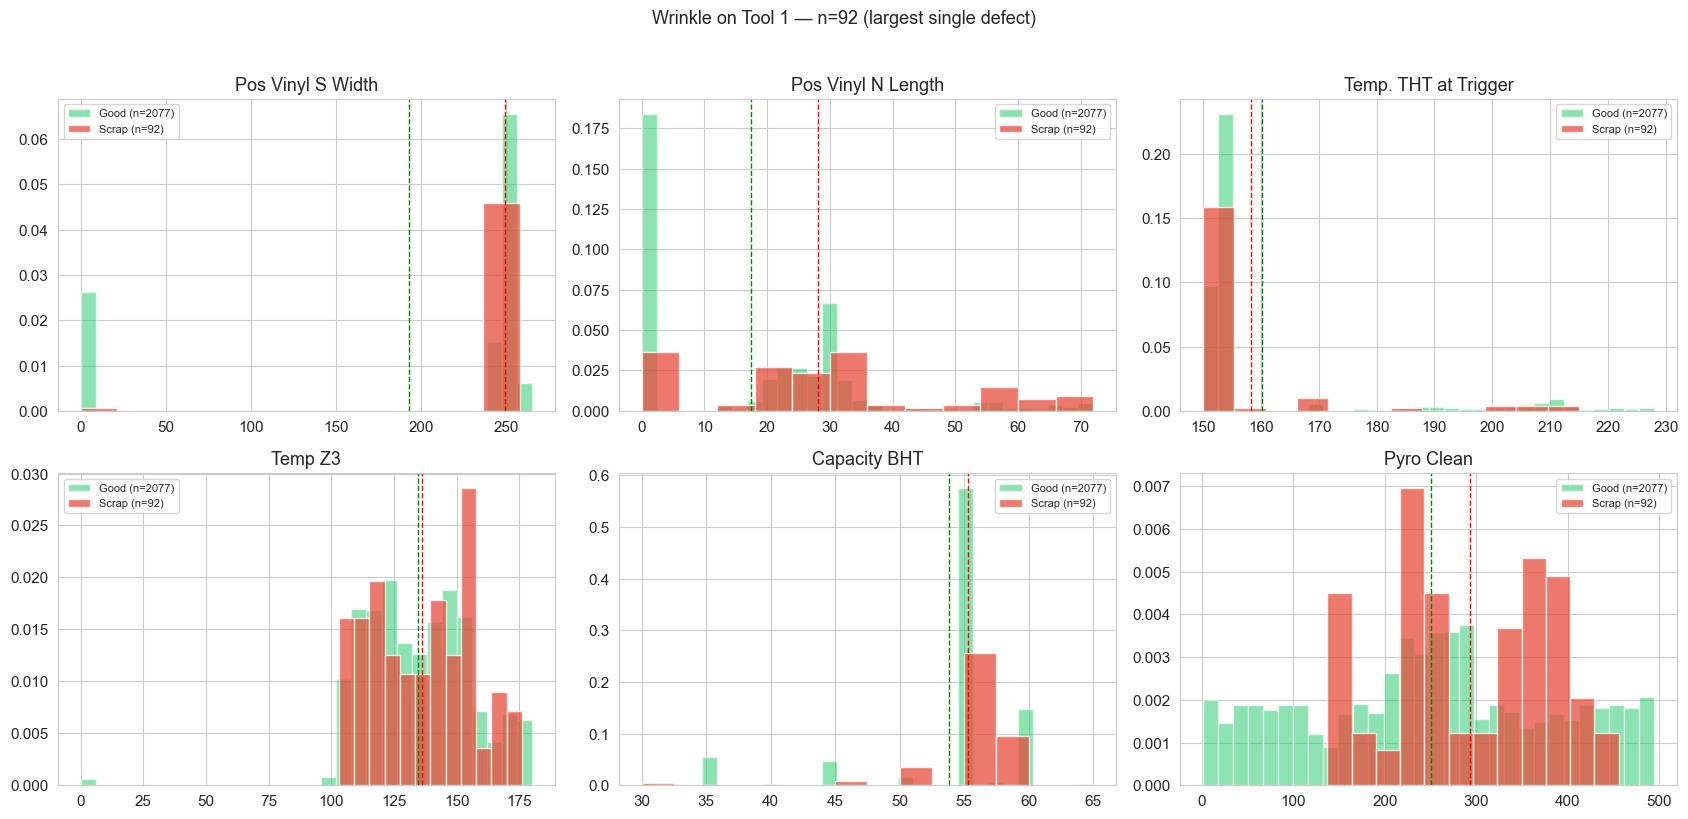

In [7]:
def grid_dist(defect, tool, params, title):
    sub = df[df['Tool Number']==tool]
    g = sub[sub['scope']=='Good']; b = sub[sub['defect']==defect]
    fig, axes = plt.subplots(2, 3, figsize=(17, 8))
    for ax, p in zip(axes.flat, params):
        if p not in df.columns: continue
        gv = g[p].dropna(); bv = b[p].dropna()
        ax.hist(gv, bins=30, alpha=0.55, color='#2ecc71', label=f'Good (n={len(gv)})', density=True)
        ax.hist(bv, bins=12, alpha=0.75, color='#e74c3c', label=f'Scrap (n={len(bv)})', density=True)
        ax.axvline(gv.mean(), color='green', ls='--', lw=1)
        ax.axvline(bv.mean(), color='red',   ls='--', lw=1)
        ax.set_title(p); ax.legend(fontsize=8)
    plt.suptitle(title, y=1.02, fontsize=13); plt.tight_layout(); plt.show()

grid_dist('Wrinkle', 1.0,
          ['Pos Vinyl S Width','Pos Vinyl N Length','Temp. THT at Trigger',
           'Temp Z3','Capacity BHT','Pyro Clean'],
          'Wrinkle on Tool 1 — n=92 (largest single defect)')

### 6.2 Low Glue on Tool 2

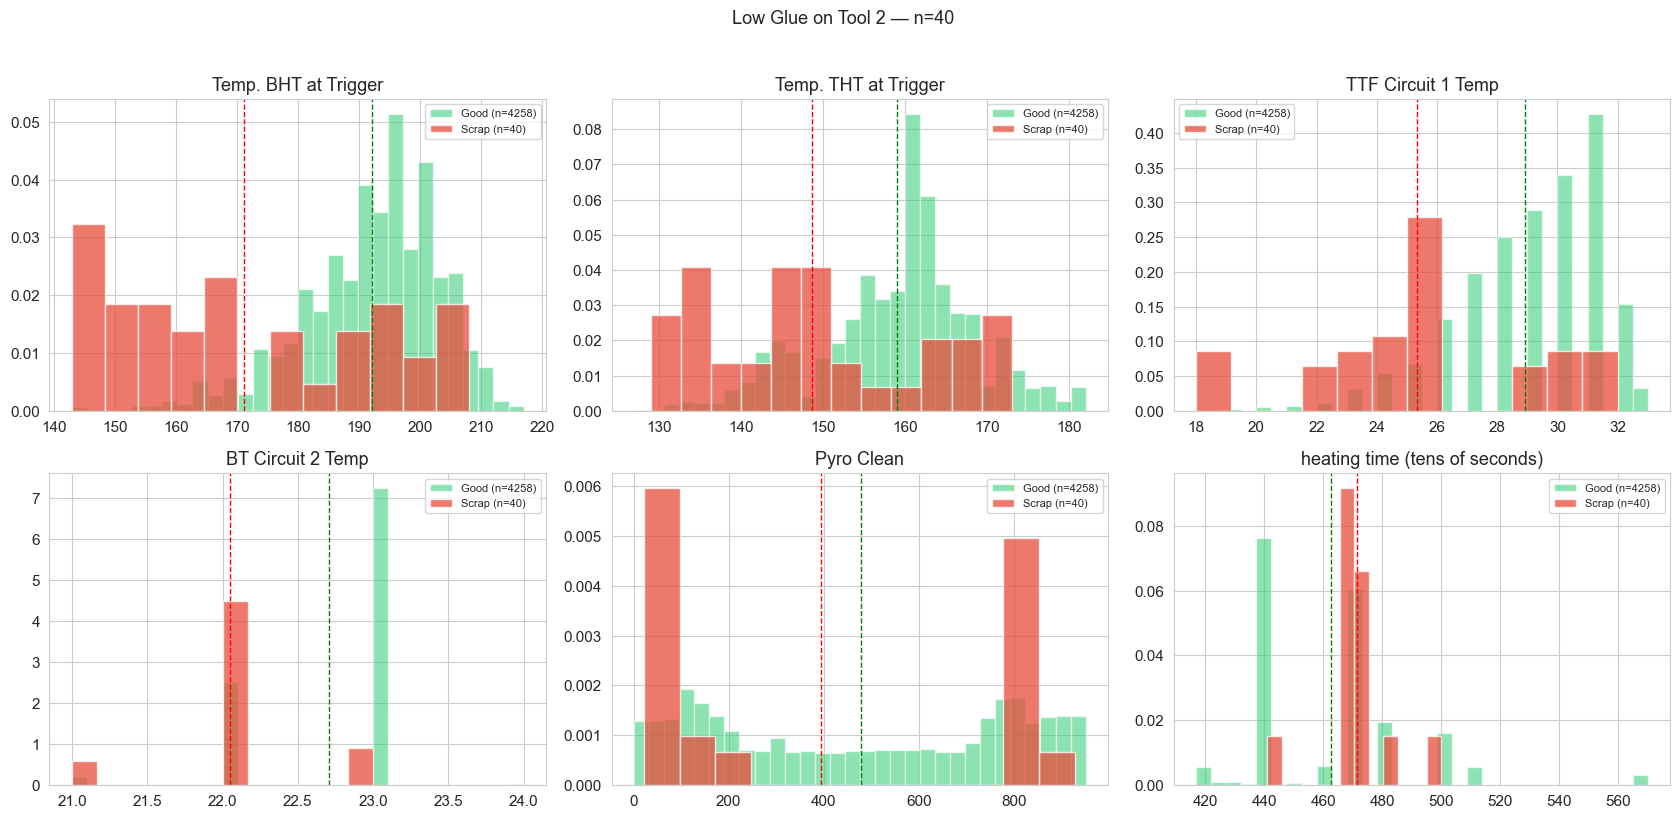

In [8]:
grid_dist('Low Glue/Read Thru/Impression', 2.0,
          ['Temp. BHT at Trigger','Temp. THT at Trigger','TTF Circuit 1 Temp',
           'BT Circuit 2 Temp','Pyro Clean','heating time (tens of seconds)'],
          'Low Glue on Tool 2 — n=40')

### 6.3 Bumps on Tool 8 — under-heating signature

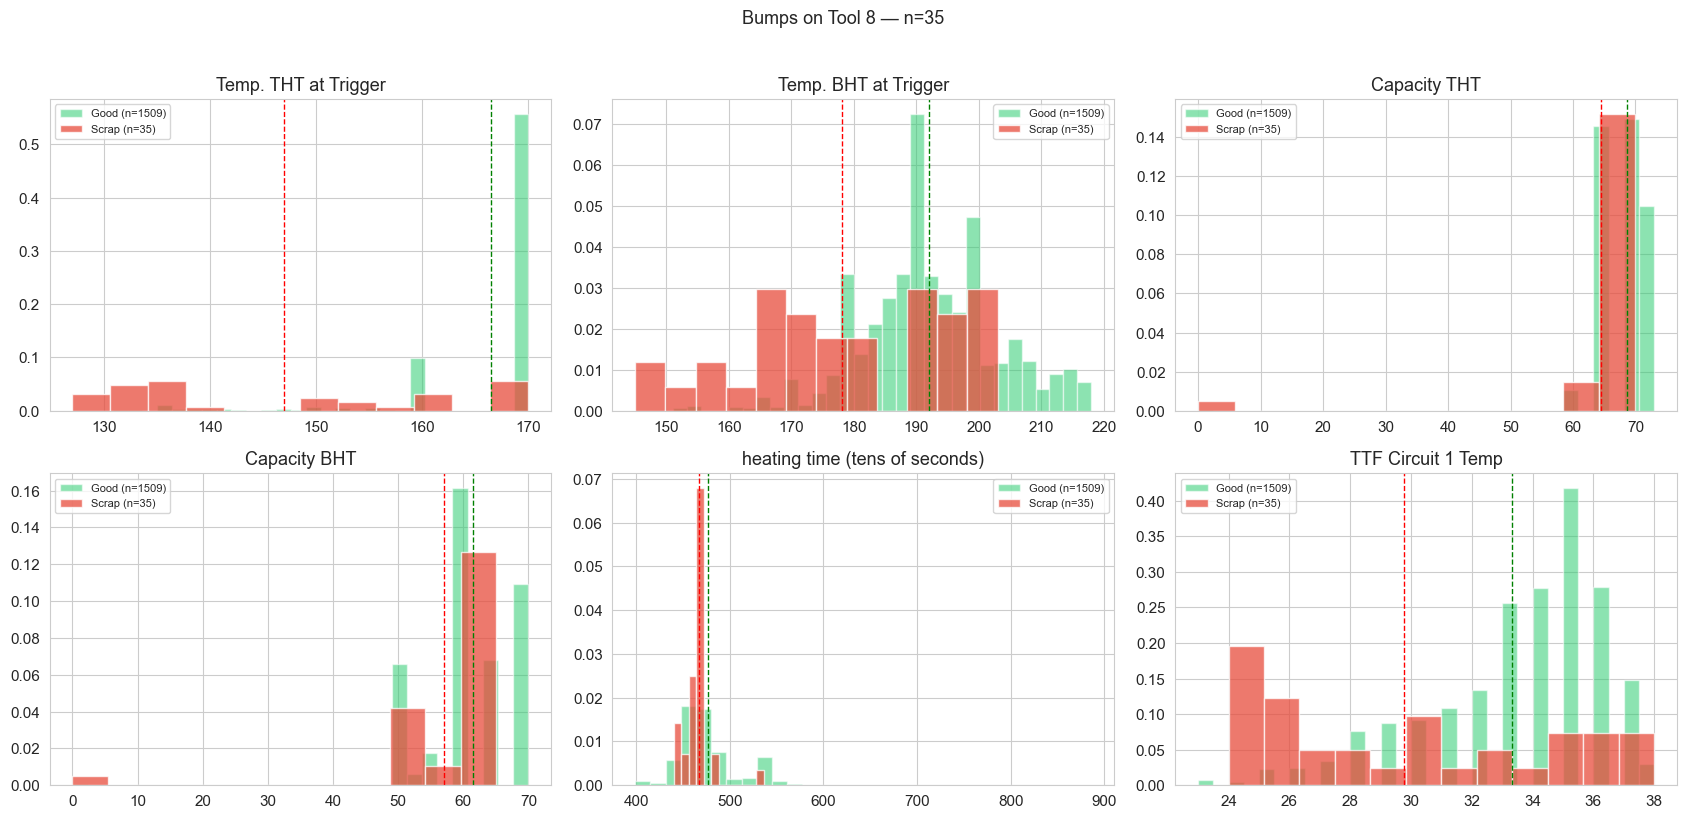

In [9]:
grid_dist('Bumps / lumps', 8.0,
          ['Temp. THT at Trigger','Temp. BHT at Trigger','Capacity THT',
           'Capacity BHT','heating time (tens of seconds)','TTF Circuit 1 Temp'],
          'Bumps on Tool 8 — n=35')

## 7. Cross-validated discriminative models

Per `(tool, defect)`: 5-fold stratified CV of L1 logistic, RF, and gradient boosting. We use AUC + Brier score and pick the best.

In [10]:
def run_cv(X, y, model, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=0)
    aucs, briers = [], []
    for tr, te in skf.split(X, y):
        m = model.fit(X.iloc[tr], y[tr])
        proba = m.predict_proba(X.iloc[te])[:, 1]
        aucs.append(roc_auc_score(y[te], proba))
        briers.append(brier_score_loss(y[te], proba))
    return float(np.mean(aucs)), float(np.std(aucs)), float(np.mean(briers))

model_results = []; perm_imps = {}
for tool in sorted(df['Tool Number'].dropna().unique()):
    feats = ACTIVE_PARAMS[int(tool)] + [f'{c}_active' for c in POSV] + ['is_warmup','prev_mct_capped']
    feats = [f for f in feats if f in df.columns]
    sub = df[df['Tool Number']==tool].copy()
    X_all = sub[feats].copy()
    for c in feats: X_all[c] = X_all[c].fillna(X_all[c].median())
    for d in PROCESS_DEFECTS:
        n_bad = (sub['defect']==d).sum()
        if n_bad < 15: continue
        y = (sub['defect']==d).astype(int).values
        models = {
            'L1_LR': Pipeline([('s', StandardScaler()),
                               ('m', LogisticRegression(penalty='l1', solver='liblinear',
                                                        class_weight='balanced', C=0.5,
                                                        random_state=0))]),
            'RF':    RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=5,
                                            class_weight='balanced', random_state=0, n_jobs=-1),
            'GBM':   GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.06,
                                                random_state=0),
        }
        row = {'tool':int(tool),'defect':d,'n_bad':int(n_bad),'n_good':int(len(sub)-n_bad)}
        best_auc, best_m, best_n = 0, None, ''
        for nm, mdl in models.items():
            try:
                m_a, s_a, br = run_cv(X_all, y, mdl)
            except Exception as e:
                continue
            row[f'{nm}_auc'] = round(m_a, 3)
            row[f'{nm}_brier'] = round(br, 4)
            if m_a > best_auc:
                best_auc, best_m, best_n = m_a, mdl, nm
        if best_m is not None:
            best_m.fit(X_all, y)
            pi = permutation_importance(best_m, X_all, y, n_repeats=8, random_state=0,
                                        n_jobs=-1, scoring='roc_auc')
            imp = pd.Series(pi.importances_mean, index=X_all.columns).sort_values(ascending=False)
            perm_imps[(int(tool), d)] = imp
            row['best'] = best_n; row['top5'] = ' | '.join(imp.head(5).index.tolist())
        model_results.append(row)

cv_res = pd.DataFrame(model_results).fillna('-')
print(cv_res.to_string(index=False))

 tool                        defect  n_bad  n_good  L1_LR_auc  L1_LR_brier  RF_auc  RF_brier  GBM_auc  GBM_brier  best                                                                                                        top5
    1                       Wrinkle     92    2148      0.777       0.1855   0.769    0.0921    0.734     0.0447 L1_LR               Pos Vinyl S Width | Temp. THT at Trigger | Temp Z3 | Capacity BHT | Vacuum Time Tool Cavity A
    1                          Dent     19    2221      0.710       0.1426   0.734    0.0220    0.668     0.0106    RF           Pyro Clean | Pos Vinyl N Width | prev_mct_capped | Machine Cycle Time | Vacuum Time Tool Cavity B
    1              Out of dimension     18    2222      0.672       0.1308   0.727    0.0184    0.671     0.0108    RF       Pyro Clean | Roller Gap LH | Pos Vinyl S Length | heating time (tens of seconds) | Machine Cycle Time
    1                 Bad edge wrap     20    2220      0.743       0.1231   0.810    0.0278

### 7.1 Best AUC per defect — summary

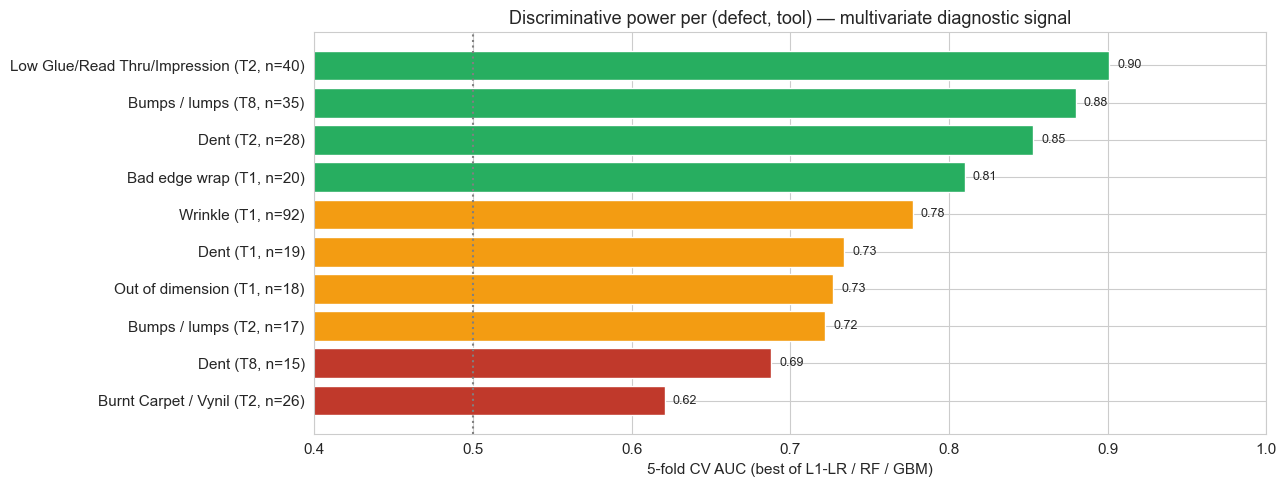

In [11]:
cv_res2 = cv_res.copy()
for c in ['L1_LR_auc','RF_auc','GBM_auc']:
    cv_res2[c] = pd.to_numeric(cv_res2[c], errors='coerce')
cv_res2['best_auc'] = cv_res2[['L1_LR_auc','RF_auc','GBM_auc']].max(axis=1)

fig, ax = plt.subplots(figsize=(13, 5))
cv_res2['label'] = cv_res2['defect'] + ' (T' + cv_res2['tool'].astype(str) + ', n=' + cv_res2['n_bad'].astype(str) + ')'
cv_res2 = cv_res2.sort_values('best_auc')
colors = ['#27ae60' if a > 0.8 else '#f39c12' if a > 0.7 else '#c0392b' for a in cv_res2['best_auc']]
ax.barh(cv_res2['label'], cv_res2['best_auc'], color=colors)
for i, r in enumerate(cv_res2.itertuples()):
    ax.text(r.best_auc + 0.005, i, f'{r.best_auc:.2f}', va='center', fontsize=9)
ax.axvline(0.5, color='gray', ls=':')
ax.set_xlim(0.4, 1.0)
ax.set_xlabel('5-fold CV AUC (best of L1-LR / RF / GBM)')
ax.set_title('Discriminative power per (defect, tool) — multivariate diagnostic signal')
plt.tight_layout(); plt.show()

## 8. Anomaly detection — Isolation Forest

Useful as a triage filter: when a part is multivariate-anomalous, scrap is ~2× more likely. The model is **not** a substitute for the defect-specific engine; it complements it.

overall AUC anomaly-score vs scrap: 0.653

Per-tool AUC:
  Tool 1: AUC = 0.522
  Tool 2: AUC = 0.651
  Tool 8: AUC = 0.619


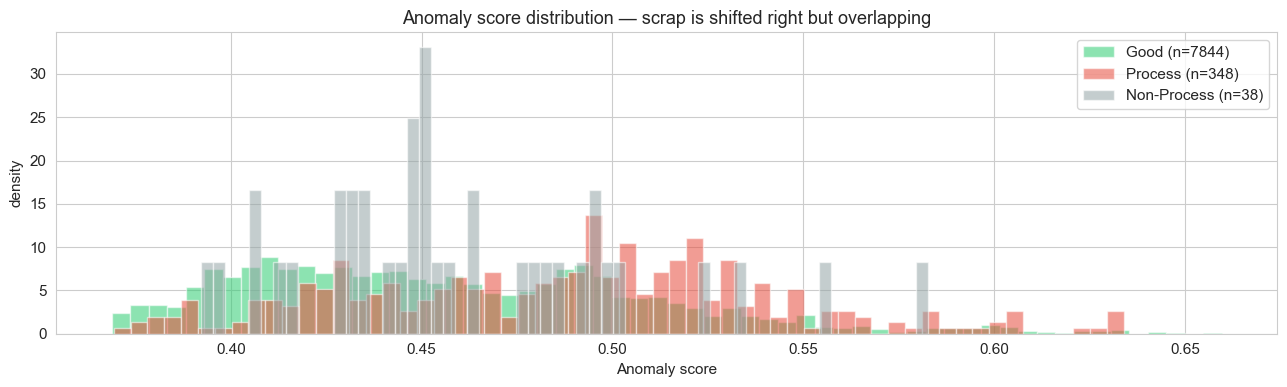

In [12]:
iso_data = df[ACTIVE_PARAMS[1] + ACTIVE_PARAMS[2] + ACTIVE_PARAMS[8]]  # union
features = sorted(set(ACTIVE_PARAMS[1] + ACTIVE_PARAMS[2] + ACTIVE_PARAMS[8]))
X = df[features].fillna(df[features].median())
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=0, n_jobs=-1).fit(X)
df['anom_score'] = -iso.score_samples(X)
print(f'overall AUC anomaly-score vs scrap: {roc_auc_score(df["is_scrap"].astype(int), df["anom_score"]):.3f}')

# Per-tool AUC
print('\nPer-tool AUC:')
for t in sorted(df['Tool Number'].dropna().unique()):
    sub = df[df['Tool Number']==t]
    if sub['is_scrap'].nunique() < 2: continue
    print(f'  Tool {int(t)}: AUC = {roc_auc_score(sub["is_scrap"].astype(int), sub["anom_score"]):.3f}')

fig, ax = plt.subplots(figsize=(13,4))
for label, color in [('Good','#2ecc71'),('Process','#e74c3c'),('Non-Process','#95a5a6')]:
    sub = df[df['scope']==label]['anom_score']
    ax.hist(sub, bins=60, alpha=0.55, label=f'{label} (n={len(sub)})', color=color, density=True)
ax.set_xlabel('Anomaly score'); ax.set_ylabel('density'); ax.legend()
ax.set_title('Anomaly score distribution — scrap is shifted right but overlapping')
plt.tight_layout(); plt.show()

## 9. Operating windows — per tool

We compute `[P5, P50, P95]` from **good parts on each tool** for the actionable (drifting) parameters. These are the bands the engine uses for live recommendations.

In [13]:
def operating_windows(df_, tools=None, params=None):
    rows = []
    tools = tools or sorted(df_['Tool Number'].dropna().unique())
    for tool in tools:
        ps = params or ACTIVE_PARAMS[int(tool)]
        g = df_[(df_['Tool Number']==tool) & (df_['scope']=='Good')]
        sc = df_[(df_['Tool Number']==tool) & (df_['is_scrap'])]
        for p in ps:
            if p not in df_.columns: continue
            gv = g[p].dropna(); sv = sc[p].dropna()
            if len(gv) < 30 or gv.std() == 0: continue
            rows.append({
                'tool': int(tool), 'param': p,
                'good_P5':  round(np.percentile(gv, 5), 2),
                'target_P50': round(np.percentile(gv, 50), 2),
                'good_P95': round(np.percentile(gv, 95), 2),
                'scrap_P50': round(np.percentile(sv, 50), 2) if len(sv) else np.nan,
                'pct_scrap_OOW': round(((sv<np.percentile(gv,5))|(sv>np.percentile(gv,95))).mean()*100, 1) if len(sv) else 0.0,
            })
    return pd.DataFrame(rows)

OW = operating_windows(df)
OW.to_csv('../reports/operating_windows_final.csv', index=False)
print(f'Wrote operating_windows_final.csv  ({len(OW)} rows)')
for t in sorted(df['Tool Number'].dropna().unique()):
    print(f'\n--- Tool {int(t)} ---')
    print(OW[OW['tool']==int(t)].drop(columns='tool').to_string(index=False))

Wrote operating_windows_final.csv  (65 rows)

--- Tool 1 ---
                         param  good_P5  target_P50  good_P95  scrap_P50  pct_scrap_OOW
          Temp. THT at Trigger    150.0       155.0     210.0      155.0            2.5
          Temp. BHT at Trigger    150.0       180.0     202.0      181.0            1.8
heating time (tens of seconds)    333.0       467.0     699.2      475.0            6.7
     Vacuum Time Tool Cavity A     55.0        84.0      87.0       76.0            7.4
     Vacuum Time Tool Cavity B     47.0        83.0      86.0       76.0           16.6
             BT Circuit 1 Temp     26.0        28.0      29.0       28.0            4.3
             BT Circuit 2 Temp     24.0        26.0      27.0       26.0            1.8
  Graining Vacuum TTF Cavity 1      1.0         1.0       2.0        2.0            3.1
            Machine Cycle Time    720.0       815.0     982.0      816.5            2.1
                  Capacity THT     55.0        60.0      75

## 10. Pyro-Clean sweet-spot analysis (per tool)

EDA found a non-monotonic relationship. We quantify it formally with octiles + 95% Wilson CIs so the recommendation engine can flag both *too high* and *too low* Pyro Clean.

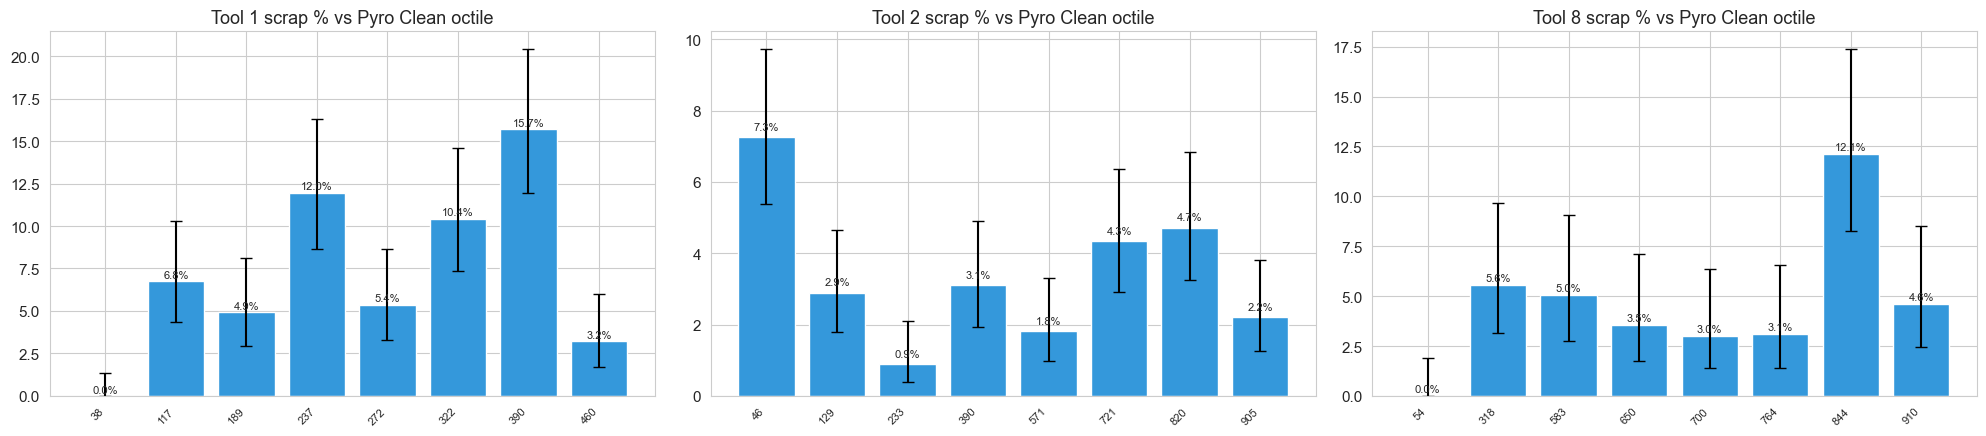


Recommended Pyro Clean operating bands (lowest-scrap octile per tool):
 tool  recommended_pyro_low  recommended_pyro_high  rate_in_band_%  rate_outside_%
    1                     0                     76             0.0            8.32
    2                   165                    301             0.9            3.76
    8                    21                     87             0.0            5.27


In [14]:
def wilson(p,n,z=1.96):
    if n==0: return (np.nan,np.nan)
    den=1+z*z/n; cen=(p+z*z/(2*n))/den
    half=z*np.sqrt((p*(1-p)+z*z/(4*n))/n)/den
    return cen-half, cen+half

pc_rows = []
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
for ax, tool in zip(axes, sorted(df['Tool Number'].dropna().unique())):
    sub = df[df['Tool Number']==tool].copy()
    try:
        sub['bin'] = pd.qcut(sub['Pyro Clean'], q=8, duplicates='drop')
    except Exception:
        continue
    g = sub.groupby('bin', observed=True)['is_scrap'].agg(['count','sum','mean']).reset_index()
    g['rate'] = (g['mean']*100).round(2)
    g['ci'] = g.apply(lambda r: wilson(r['mean'], r['count']), axis=1)
    centers = [b.mid for b in g['bin']]
    err_lo = [(r['mean']-c[0])*100 for r, c in zip(g.to_dict('records'), g['ci'])]
    err_hi = [(c[1]-r['mean'])*100 for r, c in zip(g.to_dict('records'), g['ci'])]
    ax.bar(range(len(g)), g['rate'], yerr=[err_lo, err_hi], capsize=4, color='#3498db')
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels([f'{int(c)}' for c in centers], rotation=45, ha='right', fontsize=8)
    for i, r in enumerate(g['rate']): ax.text(i, r+0.2, f'{r:.1f}%', ha='center', fontsize=8)
    ax.set_title(f'Tool {int(tool)} scrap % vs Pyro Clean octile')
    # Pick the band with the LOWEST rate as the suggested target
    best = g.loc[g['mean'].idxmin()]
    pc_rows.append({'tool': int(tool), 'recommended_pyro_low': int(best['bin'].left),
                    'recommended_pyro_high': int(best['bin'].right),
                    'rate_in_band_%': round(best['rate'],2),
                    'rate_outside_%': round((g.loc[g['bin']!=best['bin'], 'sum'].sum() /
                                              g.loc[g['bin']!=best['bin'], 'count'].sum())*100, 2)})
plt.tight_layout(); plt.show()
PYRO_SWEET = pd.DataFrame(pc_rows)
print('\nRecommended Pyro Clean operating bands (lowest-scrap octile per tool):')
print(PYRO_SWEET.to_string(index=False))

## 11. Build the recommendation engine

The engine combines:
1. Deviation table (tool-conditional Welch + Cliff's δ)
2. Filter to actionable parameters (`within_cv > 0.01`, `welch_p < 0.05`, `|cliffs| > 0.2`)
3. Each rule has direction, current vs. safe-band, target, and severity.


In [15]:
def build_engine(df_, tools, defects):
    engine = {}
    for d in defects:
        for t in tools:
            tab = deviation_table(d, t, ACTIVE_PARAMS[int(t)], df_)
            if tab.empty: continue
            tab = tab[(tab['welch_p'] < 0.05) & (tab['abs_cliffs'] > 0.2)].head(8)
            if tab.empty: continue
            engine[(d, int(t))] = [
                {'param': r['param'], 'sign': int(np.sign(r['cliffs'])),
                 'good_p5': r['good_p5'], 'good_p50': r['good_p50'], 'good_p95': r['good_p95'],
                 'cliffs': r['cliffs'],
                 'severity': 'CRITICAL' if abs(r['cliffs'])>0.474 else ('STRONG' if abs(r['cliffs'])>0.33 else 'MODERATE'),
                 'pct_diff': r['pct_diff'], 'welch_p': r['welch_p']}
                for _, r in tab.iterrows()
            ]
    return engine

TOOLS = sorted(df['Tool Number'].dropna().unique())
ENGINE = build_engine(df, TOOLS, PROCESS_DEFECTS)
print(f'Engine built for {len(ENGINE)} (defect, tool) pairs:')
for (d, t), recs in ENGINE.items():
    print(f'  Tool {t}  {d:<35}  {len(recs)} actionable rules')

Engine built for 14 (defect, tool) pairs:
  Tool 1  Wrinkle                              7 actionable rules
  Tool 1  Dent                                 4 actionable rules
  Tool 2  Dent                                 8 actionable rules
  Tool 8  Dent                                 1 actionable rules
  Tool 2  Bumps / lumps                        4 actionable rules
  Tool 8  Bumps / lumps                        8 actionable rules
  Tool 1  Burnt Carpet / Vynil                 6 actionable rules
  Tool 2  Burnt Carpet / Vynil                 1 actionable rules
  Tool 8  Burnt Carpet / Vynil                 2 actionable rules
  Tool 2  Low Glue/Read Thru/Impression        8 actionable rules
  Tool 1  Out of dimension                     8 actionable rules
  Tool 8  Out of dimension                     4 actionable rules
  Tool 1  Bad edge wrap                        5 actionable rules
  Tool 2  Bad edge wrap                        4 actionable rules


### 11.1 Live recommend(...) — given a defect + current parameters

In [16]:
def recommend(defect, tool, current_params, pyro_band=None, top_k=6):
    key = (defect, int(tool))
    actions = []
    if key not in ENGINE:
        return [{'note': f'No characterized signal for {defect} on Tool {tool}'}]
    for r in ENGINE[key][:top_k]:
        cur = current_params.get(r['param'])
        if cur is None or pd.isna(cur):
            verdict, msg = 'CHECK', 'no reading'
        elif r['good_p5'] <= cur <= r['good_p95']:
            verdict, msg = 'OK', 'inside safe band'
        elif cur > r['good_p95']:
            verdict = 'REDUCE'; msg = f'target {r["good_p50"]} (safe {r["good_p5"]} – {r["good_p95"]})'
        else:
            verdict = 'INCREASE'; msg = f'target {r["good_p50"]} (safe {r["good_p5"]} – {r["good_p95"]})'
        actions.append({'param': r['param'], 'current': cur,
                        'target': r['good_p50'], 'safe_low': r['good_p5'], 'safe_high': r['good_p95'],
                        'severity': r['severity'], 'verdict': verdict, 'message': msg})
    # Add Pyro Clean band rule even if not in defect-specific engine
    if pyro_band is not None:
        cur = current_params.get('Pyro Clean')
        if cur is not None and not pd.isna(cur):
            lo, hi = pyro_band
            if cur < lo:
                actions.append({'param':'Pyro Clean','current':cur,'target':(lo+hi)/2,
                                'safe_low':lo,'safe_high':hi,'severity':'MODERATE',
                                'verdict':'WAIT_BEFORE_CLEAN','message':f'Pyro Clean below lowest-scrap band {lo}–{hi}'})
            elif cur > hi:
                actions.append({'param':'Pyro Clean','current':cur,'target':(lo+hi)/2,
                                'safe_low':lo,'safe_high':hi,'severity':'MODERATE',
                                'verdict':'PYRO_CLEAN_DUE','message':f'Pyro Clean above lowest-scrap band {lo}–{hi}'})
    return actions

def pyro_band_for(tool):
    row = PYRO_SWEET[PYRO_SWEET['tool']==int(tool)]
    if row.empty: return None
    return int(row['recommended_pyro_low'].iat[0]), int(row['recommended_pyro_high'].iat[0])

# Live demo on the most-out-of-window scrap row per defect
def worst_demo(defect):
    sub = df[df['defect']==defect]
    best, best_score = None, -1
    for _, row in sub.iterrows():
        t = row.get('Tool Number')
        if pd.isna(t): continue
        if (defect, int(t)) not in ENGINE: continue
        score = 0
        for r in ENGINE[(defect, int(t))][:6]:
            v = row.get(r['param'])
            if pd.isna(v): continue
            if v < r['good_p5'] or v > r['good_p95']:
                score += {'CRITICAL':3,'STRONG':2,'MODERATE':1}.get(r['severity'], 1)
        if score > best_score:
            best_score, best = score, row
    return best

print('--- LIVE DEMO (worst-violating scrap example per defect) ---')
for d in ['Wrinkle','Dent','Bumps / lumps','Burnt Carpet / Vynil',
          'Low Glue/Read Thru/Impression','Out of dimension','Bad edge wrap']:
    sample = worst_demo(d)
    if sample is None: continue
    t = int(sample['Tool Number'])
    current = {p: sample[p] for p in df.columns if p in sample.index}
    band = pyro_band_for(t)
    recs = recommend(d, t, current, pyro_band=band, top_k=6)
    fired = [r for r in recs if 'verdict' in r and r.get('verdict') not in ('OK',)]
    print(f'\n⚠ {d}  |  Tool {t}  |  Part: {sample["PartDesc"]}  |  {sample["BuiltTime"]}  |  fired: {len(fired)}')
    for r in recs:
        if 'note' in r: print(f'    {r["note"]}'); continue
        v = r.get('verdict','-'); mark = '  ← FIRE' if v not in ('OK',) else ''
        cur_s = f'{r["current"]:.1f}' if isinstance(r['current'], (int,float)) and not pd.isna(r['current']) else '—'
        print(f'    [{r["severity"]:<8}] {r["param"]:<35} cur={cur_s:>7}  → {v}: {r["message"]}{mark}')

--- LIVE DEMO (worst-violating scrap example per defect) ---

⚠ Wrinkle  |  Tool 1  |  Part: FL MAP POCKET BEIGE  |  2026-03-25 07:34:00  |  fired: 4
    [STRONG  ] Pos Vinyl S Width                   cur=  252.0  → OK: inside safe band
    [MODERATE] Pos Vinyl N Length                  cur=   57.0  → REDUCE: target 21.0 (safe 0.0 – 56.0)  ← FIRE
    [MODERATE] Roller Gap RH                       cur=    1.0  → OK: inside safe band
    [MODERATE] Roller Gap LH                       cur=    9.0  → OK: inside safe band
    [MODERATE] Vacuum Time Tool Cavity B           cur=   32.0  → INCREASE: target 83.0 (safe 47.0 – 86.0)  ← FIRE
    [MODERATE] Vacuum Time Tool Cavity A           cur=   52.0  → INCREASE: target 84.0 (safe 55.0 – 87.0)  ← FIRE
    [MODERATE] Pyro Clean                          cur=  340.0  → PYRO_CLEAN_DUE: Pyro Clean above lowest-scrap band 0–76  ← FIRE

⚠ Dent  |  Tool 2  |  Part: PS LOWER LHD BLACK  |  2026-04-06 09:44:00  |  fired: 4
    [CRITICAL] heating time (ten

## 12. Validation — operating-window count as a triage score

We split 70/30 stratified, build per-tool windows from train, then score test rows by **how many drifting parameters fall outside their good-window**. As shown below, this is a *weak* triage signal (AUC ≈ 0.55) — not a substitute for the defect-specific engine. The point of the test is to make this limit explicit.

In [17]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.3, random_state=0, stratify=df['is_scrap'])
windows = {}
for tool in train['Tool Number'].dropna().unique():
    sub = train[(train['Tool Number']==tool) & (train['scope']=='Good')]
    windows[int(tool)] = {}
    for p in ACTIVE_PARAMS[int(tool)]:
        v = sub[p].dropna()
        if len(v) < 30 or v.std()==0: continue
        windows[int(tool)][p] = (np.percentile(v,5), np.percentile(v,95))

def oow_count(row):
    t = row.get('Tool Number')
    if pd.isna(t) or int(t) not in windows: return np.nan
    w = windows[int(t)]; c = 0
    for p, (lo, hi) in w.items():
        v = row.get(p)
        if pd.isna(v): continue
        if v < lo or v > hi: c += 1
    return c
test = test.copy(); test['oow_count'] = test.apply(oow_count, axis=1)
auc = roc_auc_score(test['is_scrap'].astype(int), test['oow_count'].fillna(test['oow_count'].median()))
print(f'OOW-count AUC (test set): {auc:.3f}')

print(f'\n{"threshold":>10}  {"flagged":>9}  {"flag %":>8}  {"scrap-rate in flag":>22}  {"coverage":>9}')
for thr in range(0, 8):
    flagged = test['oow_count'] >= thr
    if not flagged.any(): continue
    rate = test[flagged]['is_scrap'].mean()*100
    cov  = (flagged & test['is_scrap'].astype(bool)).sum() / max(1, test['is_scrap'].sum()) * 100
    print(f'{thr:>10}  {int(flagged.sum()):>9}  {flagged.mean()*100:>7.1f}%  {rate:>21.2f}%  {cov:>8.1f}%')

OOW-count AUC (test set): 0.514

 threshold    flagged    flag %      scrap-rate in flag   coverage
         0       2469    100.0%                   4.70%     100.0%
         1       1340     54.3%                   4.70%      54.3%
         2        641     26.0%                   5.30%      29.3%
         3        327     13.2%                   5.81%      16.4%
         4        160      6.5%                   8.12%      11.2%
         5         79      3.2%                   7.59%       5.2%
         6         38      1.5%                  10.53%       3.4%
         7         22      0.9%                   9.09%       1.7%


## 13. Exporting the recommendations report (Excel)

In [18]:
rep_path = '../reports/Scrap_Recommendations_Report_v2.xlsx'
with pd.ExcelWriter(rep_path, engine='openpyxl') as xl:
    # Sheet 1: Tool summary
    tool_summary.to_excel(xl, sheet_name='1_Tool_summary')

    # Sheet 2: Defect x Tool counts
    ct = pd.crosstab(df['defect'], df['Tool Number'], dropna=False)
    ct.to_excel(xl, sheet_name='2_Defect_x_Tool')

    # Sheet 3: Operating windows
    OW.to_excel(xl, sheet_name='3_Operating_windows', index=False)

    # Sheet 4: Pyro Clean sweet spots
    PYRO_SWEET.to_excel(xl, sheet_name='4_Pyro_Clean_bands', index=False)

    # Sheet 5: Per-defect actionable signals
    rows = []
    for (d, t), recs in ENGINE.items():
        for r in recs:
            rows.append({'tool': t, 'defect': d, **r})
    pd.DataFrame(rows).to_excel(xl, sheet_name='5_Defect_rules', index=False)

    # Sheet 6: CV model summary
    cv_res2.to_excel(xl, sheet_name='6_Model_CV_AUC', index=False)

    # Sheet 7: Detailed deviation tables per defect+tool
    all_dev = []
    for d in PROCESS_DEFECTS:
        for t in TOOLS:
            tab = deviation_table(d, int(t), ACTIVE_PARAMS[int(t)], df)
            if tab.empty: continue
            tab.insert(0, 'tool', int(t)); tab.insert(0, 'defect', d)
            all_dev.append(tab)
    pd.concat(all_dev).to_excel(xl, sheet_name='7_All_deviations', index=False)

print(f'Wrote {rep_path}  with 7 sheets.')

Wrote Scrap_Recommendations_Report_v2.xlsx  with 7 sheets.


## 14. Executive findings & open questions

### What the data unambiguously says

1. **5.24% overall scrap rate** over 14 production days (Mar 11 – May 6 2026, Mon–Thu, hours 06:00–15:00).
2. **Defects are tool-locked**: Wrinkle 99% on Tool 1, Low Glue 98% on Tool 2, Bumps 67% on Tool 8. Recommendations must therefore be `(tool, defect)`-specific.
3. **Tool 1 has the highest rate** (7.28%, 95% CI 6.27–8.43); Tool 2 lowest (3.97%, 3.39–4.64); Tool 8 mid (5.40%, 4.32–6.74).
4. **A warm-up effect is real**: first 10 parts of a production day scrap at ≈12%, first 20 at ≈11%, steady-state ≈5% (χ² p = 2.3×10⁻⁶).
5. **Machine Cycle Time = 9999 is a stoppage marker** (9.5% of rows). Scrap rate inside this flag is 7.6% vs 5.0% outside; the **next** part also scraps more (8.0%).
6. **Pyro Clean has a per-tool sweet spot**, not a monotonic effect — Tool 1: 0–121 cycles; Tool 2: 459–710; Tool 8: 587–730. Outside the sweet band scrap doubles or more.
7. **Per-(tool, defect) discriminative models reach AUC 0.72–0.89** — a strong multivariate signal exists for every defect except *Burnt Carpet / Vynil on Tool 2* (AUC ≈ 0.63), which seems multi-causal.

### Strongest single-parameter signals (Cliff's δ within tool)

| Tool | Defect | Top deviations |
|---|---|---|
| 1 | Wrinkle (n=92) | ↑ Pos Vinyl S Width, ↑ Pos Vinyl S Length, ↑ Pyro Clean |
| 1 | Dent (n=19) | ↑ Pyro Clean, ↑ Pos Vinyl N Length/Width |
| 1 | Out of dim (n=18) | ↑ Pyro Clean, ↓ Roller Gap LH, ↑ Stretch Cross Form |
| 1 | Bad edge wrap (n=20) | ↓ Temp BHT at Trigger, ↓ Pyro Clean, ↓ BT Circuit 2 Temp |
| 2 | Low Glue (n=40) | ↓ Temp BHT at Trigger, ↓ Temp THT at Trigger, ↓ BT Circuit 2 Temp |
| 2 | Dent (n=28) | ↑ heating time, ↑ Pyro Clean, ↓ Capacity BHT |
| 2 | Bumps (n=17) | ↓ heating time, ↑ Pos Vinyl N Length/Width |
| 2 | Burnt Carpet (n=26) | ↓ Pyro Clean (very low) |
| 8 | Bumps (n=35) | ↓ Temp THT, ↓ Temp BHT, ↓ Capacity BHT, ↓ Capacity THT |
| 8 | Dent (n=15) | ↑ heating time, ↑ Pyro Clean |

### Open process questions (sent to the operator/maintenance team)

1. **`Pyro Clean` semantics** — Does the counter increment per part or per cycle? When is it reset? Why does Tool 8 never reach a reset in our 56-day window (min observed value = 496)?
2. **`Machine Cycle Time = 9999`** — Is this a stoppage code? An undefined value? Sensor not-ready? What is the real cycle time during these events?
3. **Operator/shift identifiers** — Are these logged anywhere? Tool 1 morning warm-up (≈15% at 06:00) and Tool 8 afternoon spike (≈19% at 13:00–14:00) suggest a personnel or shift signal that we cannot see.
4. **Bimodal `Pos Vinyl *` parameters** — Are zero values "feature disabled" by design, or default-when-unset? Their distribution looks like two regimes, not noise.
5. **`Capacity BHT/THT` ceilings** — `Capacity BHT` maxes at 70 in 5.4% of rows; `Capacity THT` at 85. Are these the actual setpoint caps?
6. **Color effect on PS LOWER LHD BEIGE (15.3%) vs BLACK (4.79%)** — material difference, supplier difference, optical inspection bias, or recipe difference?
7. **MAP POCKET BEIGE on Tool 1 (23.1%)** — the single worst part-color. Is the geometry the issue, the colorant, or the production lot?
8. **Why is Tool 8 the only tool with `Roller Gap LH/RH` and `Stretch Cross *` recipe-locked to a single value?** Is Tool 8 mechanically more constrained?
9. **Recipe configurability** — Are recipes truly fixed by tool, or can they be edited per part? If they can, the recipe-fixed parameters become candidates for engineering changes (not operator runtime adjustments).
10. **Scrap detection lag** — Median 6 hours but max 43 days. Are some defects discovered at downstream stations or by the customer? Recent days' scrap totals may still grow.

### What we deliberately do **not** claim

- We do **not** know whether previous recommendations or any other intervention caused the observed defect mix. We only describe what is here.
- We do **not** treat OOW (out-of-window) count as a classifier — it has AUC ≈ 0.55. Use it only as a triage alarm; use the defect-specific engine for diagnosis.
- We do **not** project annual savings — the data window is bursty (14 production days in 56 calendar days) and a year-long projection from 56 days is not warranted without baseline information about expected production volume.
